In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
# Notebooks run from the notebooks folder, so the src folder is added to the path.
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, rasterio, matplotlib.pyplot as plt
from tqdm import tqdm
import config

In [2]:
import json
from prepare import load_chips, flatten
from metrics import split_chips, flat_ndvi, score, best_threshold

train, val, test = split_chips(load_chips())
# The threshold is chosen on training tiles only, then saved for later notebooks.
threshold = best_threshold(flat_ndvi(train), flatten(train, "msk"), np.arange(-0.10, 0.60, 0.02))
config.NDVI_THRESHOLD_FILE.write_text(json.dumps({"threshold": float(threshold)}))
print("NDVI threshold:", round(threshold, 2))

Tiles: 1127 train, 392 validation, 392 test
NDVI threshold: -0.02


In [3]:
# The training threshold is applied to the test tiles without adjustment.
test_ndvi, test_truth, test_classes = flat_ndvi(test), flatten(test, "msk"), flatten(test, "lc8")
print({name: round(value, 3) for name, value in score(test_ndvi > threshold, test_truth).items()})

{'iou': np.float64(0.474), 'precision': np.float64(0.614), 'recall': np.float64(0.676), 'f1': np.float64(0.643)}


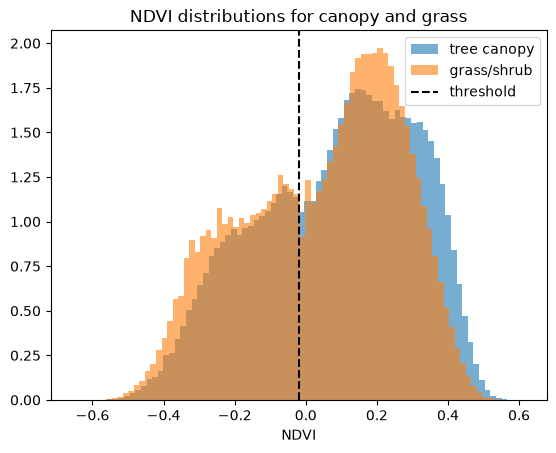

In [4]:
# NDVI distributions for tree and grass pixels; their overlap is error no threshold can remove.
for cls in [config.CANOPY_CLASS, config.GRASS_CLASS]:
    plt.hist(test_ndvi[test_classes == cls], bins=80, alpha=0.6, density=True, label=config.CLASS_NAMES[cls])
plt.axvline(threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("NDVI"); plt.legend(); plt.title("NDVI distributions for canopy and grass")
plt.savefig(config.FIGURES / "02_ndvi_histogram.png", dpi=120, bbox_inches="tight"); plt.show()

The NDVI histogram shows that tree canopy and grass/shrub cannot be differentiated by a set NDVI threshold. Neither type of vegetation should produce a negative NDVI value; this will be investigated in the next section.